In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("mock_data.csv")
df.head(5)

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [3]:
from sklearn import preprocessing

s1 = preprocessing.MinMaxScaler()
s2 = preprocessing.MinMaxScaler()

scaled_features = s1.fit_transform(df.drop('price',axis = 'columns'))
scaled_features


array([[0.08827586, 0.2       ],
       [0.62068966, 0.6       ],
       [0.22068966, 0.4       ],
       [0.24862069, 0.4       ],
       [0.13793103, 0.2       ],
       [0.12758621, 0.2       ],
       [0.6662069 , 0.6       ],
       [0.86206897, 0.6       ],
       [0.17586207, 0.4       ],
       [1.        , 1.        ],
       [0.34482759, 0.4       ],
       [0.68448276, 0.6       ],
       [0.06896552, 0.2       ],
       [0.10344828, 0.2       ],
       [0.5       , 0.4       ],
       [0.12931034, 0.2       ],
       [0.13103448, 0.4       ],
       [0.25517241, 0.4       ],
       [0.67931034, 0.4       ],
       [0.        , 0.        ]])

In [4]:
scaled_output = s2.fit_transform(df['price'].values.reshape(df.shape[0],1))
scaled_output

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [5]:
import sys
import os
project_root = os.path.abspath("..")
sys.path.append(project_root)
from batch_gradient_descent import batch_grad_descent

In [7]:
w, b, cost, cost_list, epoch_list = batch_grad_descent(df.drop('price',axis='columns'),scaled_output.reshape(scaled_output.shape[0],),500)
w, b, cost

(array([0.72193589, 0.72404274]),
 np.float64(-0.1969265243737243),
 np.float64(0.007736826847372846))

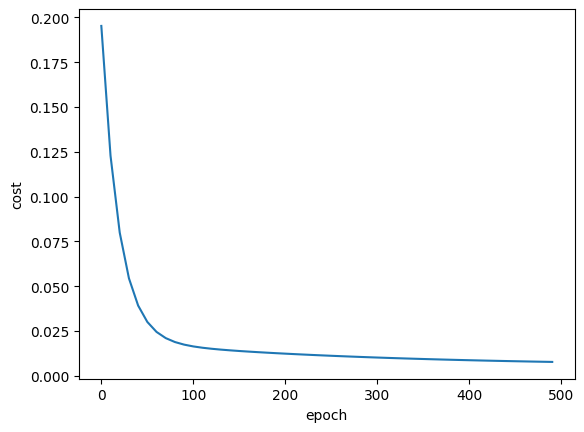

In [8]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list, cost_list)

In [9]:
def predict(area, bedrooms, w, b):
    scaled_features = s1.transform([[area, bedrooms]])[0]
    scaled_price = w[0]*scaled_features[0] + w[1] * scaled_features[1] + b
    return s2.inverse_transform([[scaled_price]])
predict(2600,4,w,b)    

d:\Projects\Tensorflow valut\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[124.55563013]])

In [10]:
predict(1000,2,w,b)

d:\Projects\Tensorflow valut\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[31.68554529]])